# Theta phase precession in hippocampal place cells

**Data:** [DANDI:000044](https://dandiarchive.org/dandiset/000044), *"Diversity in neural
firing dynamics supports both rigid and learned hippocampal sequences"*
(Grosmark & Buzsáki, *Science* 2016). Eight sessions from four Long-Evans rats
(Achilles, Buddy, Cicero, Gatsby), bilateral silicon-probe recordings from dorsal CA1
while the animal ran for water reward on a 1.6 m or 2 m linear track or a ~2.9 m
circular maze. Each NWB file contains spike-sorted units labelled excitatory or
inhibitory, a linearised position signal for the maze epoch, and a 128-channel,
1250 Hz local field potential.

**The phenomenon.** A CA1 place cell fires whenever the animal is inside that cell's
place field. O'Keefe & Recce (1993) showed that the *phase* of the ongoing 6–10 Hz
theta rhythm at which those spikes occur is not fixed: spikes occur at a late theta
phase when the animal enters the field and shift progressively earlier as the animal
crosses it, advancing by roughly a full theta cycle from field entry to field exit.
Position is therefore encoded twice over, once in firing rate and once in firing phase.

**What this notebook does.** For every place field it measures the relationship
between the fraction of the field the animal has traversed and the theta phase of each
spike, using the circular-linear regression of Kempter et al. (2012), and tests it
against a phase-shuffled null. The headline result is that the regression slope is
negative (phase advances) for the large majority of fields, in every session.

The whole notebook streams data from the DANDI S3 bucket with `remfile` and a local
disk cache; nothing is downloaded in full (each NWB file is 5–9 GB, of which we read
roughly 30 MB per session).

## Setup

In [1]:
import zlib
import numpy as np
import pandas as pd
import h5py
import remfile
import requests
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.signal import butter, filtfilt, hilbert, welch
from scipy.ndimage import gaussian_filter1d
from tqdm.auto import tqdm
import pynapple as nap

matplotlib.rcParams.update({"font.size": 9, "figure.dpi": 110,
                            "axes.spines.top": False, "axes.spines.right": False})

DANDISET, VERSION = "000044", "0.250624.0426"
CACHE_DIR = "/tmp/remfile_cache"

LFP_FS = 1250.0            # Hz, sampling rate of the stored LFP
THETA_BAND = (6.0, 10.0)   # Hz
SPEED_THRESH = 0.10        # m/s, minimum running speed
POS_BIN = 0.04             # m, spatial bin width for rate maps

# place-field selection criteria
MIN_PEAK = 1.0             # Hz, peak of the smoothed rate map
MIN_SI = 0.5               # bits/spike, Skaggs spatial information
MIN_SPIKES = 50            # in-field spikes
MIN_PASSES = 10            # traversals contributing at least one in-field spike
EDGE_FRAC = 0.075          # fraction of track length excluded at each end (linear only)
FIELD_FRAC = (0.10, 0.55)  # admissible field width, as a fraction of track length

EXAMPLE = "Achilles-10252013"

## Loading

Two details of this particular NWB conversion are worth flagging, because getting
either wrong silently corrupts the analysis:

1. The `starting_time` attribute called `rate` on the position series actually holds
   the sampling **period** (0.0256 s), not the rate. Treating it as a rate would place
   the behaviour 1500-fold past the end of the recording; treating it as `dt`
   reproduces the maze epoch boundaries exactly.
2. The linearised position is defined only while the animal is on the track proper,
   and is NaN while it sits at the reward ends. Those NaNs are dropped, which
   conveniently leaves one contiguous stretch of samples per traversal.

The dandiset mixes maze geometries: four sessions use a 1.6 m linear track, one a 2 m
linear track, and three a circular maze of ~2.9 m circumference. The maze type is read
off the name of the behaviour processing module, because the circular sessions need a
position coordinate that wraps.

In [2]:
def resolve_assets():
    """Map session name -> DANDI asset id."""
    url = f"https://api.dandiarchive.org/api/dandisets/{DANDISET}/versions/{VERSION}/assets/"
    out = {}
    for a in requests.get(url, params={"page_size": 100}).json()["results"]:
        out[a["path"].split("_ses-")[1].split("_")[0]] = a["asset_id"]
    return out


def open_session(asset_id):
    url = (f"https://api.dandiarchive.org/api/dandisets/{DANDISET}/versions/"
           f"{VERSION}/assets/{asset_id}/download/")
    return h5py.File(remfile.File(url, disk_cache=remfile.DiskCache(CACHE_DIR)), "r")


def load_position(h5):
    """Linearised position as a pynapple Tsd, plus dt and the maze geometry."""
    key = [k for k in h5["processing/behavior"] if "LinearizedPosition" in k][0]
    g = h5[f"processing/behavior/{key}"]
    g = g[list(g)[0]]
    t0 = float(g["starting_time"][()])
    dt = float(g["starting_time"].attrs["rate"])   # sampling period, see note above
    d = g["data"][:, 0]
    t = t0 + np.arange(len(d)) * dt
    ok = np.isfinite(d)
    pos = nap.Tsd(t=t[ok], d=d[ok])
    circular = key.startswith("Circular")
    length = (float(np.ceil(pos.values.max() * 100) / 100) if circular
              else float(key.split("mLinear")[0]))
    maze = dict(name=key.replace("LinearizedPosition", ""), circular=circular, length=length)
    return pos, dt, maze


def load_units(h5):
    """All sorted units as a pynapple TsGroup with cell type and location."""
    st = h5["units/spike_times"][:]
    idx = h5["units/spike_times_index"][:]
    bounds = np.r_[0, idx]
    dec = lambda a: np.array([x.decode() if isinstance(x, bytes) else x for x in a])
    tsg = nap.TsGroup({i: st[bounds[i]:bounds[i + 1]] for i in range(len(idx))})
    tsg.set_info(cell_type=dec(h5["units/cell_type"][:]),
                 location=dec(h5["units/location"][:]),
                 shank_id=h5["units/shank_id"][:])
    return tsg


def load_lfp_channel(h5, ch, t_start, t_stop):
    d = h5["processing/ecephys/LFP/LFP/data"]
    conv = float(d.attrs["conversion"])          # int16 -> volts
    i0, i1 = int(round(t_start * LFP_FS)), int(round(t_stop * LFP_FS))
    return nap.Tsd(t=np.arange(i0, i1) / LFP_FS, d=d[i0:i1, ch].astype(np.float64) * conv)


def pick_theta_channel(h5, t_start, dur=300.0, stride=4):
    """Pick the channel with the largest theta / (delta + beta) power ratio.

    The probes span 128 sites at many depths; theta amplitude varies strongly with
    depth, so the reference channel is chosen from the data rather than assumed.
    """
    d = h5["processing/ecephys/LFP/LFP/data"]
    conv = float(d.attrs["conversion"])
    i0 = int(round(t_start * LFP_FS))
    chans, ratios = np.arange(0, d.shape[1], stride), []
    for ch in chans:
        x = d[i0:i0 + int(dur * LFP_FS), ch].astype(float) * conv
        fr, P = welch(x, fs=LFP_FS, nperseg=2048)
        th = P[(fr >= THETA_BAND[0]) & (fr <= THETA_BAND[1])].mean()
        ref = P[((fr >= 2) & (fr <= 4)) | ((fr >= 12) & (fr <= 20))].mean()
        ratios.append(th / ref)
    return int(chans[int(np.argmax(ratios))]), chans, np.array(ratios)

## Preprocessing: theta phase and running epochs

Theta phase comes from a zero-phase Butterworth bandpass (6–10 Hz) followed by the
Hilbert transform, so phase 0° is the **peak** of the filtered LFP on the selected
channel. Absolute phase is not comparable across recordings (it depends on the depth
of the reference channel relative to the CA1 layers), so the quantity of interest here
is the *slope*, not the offset.

Running epochs are contiguous stretches of tracked position with speed above 10 cm/s,
split by direction of travel. On the circular maze the coordinate jumps by a full lap
at the wrap point, so displacements are taken modulo the circumference.

In [3]:
def theta_phase(lfp):
    b, a = butter(3, np.array(THETA_BAND) / (LFP_FS / 2), btype="bandpass")
    x = filtfilt(b, a, lfp.values)
    return (nap.Tsd(t=lfp.index.values, d=x),
            nap.Tsd(t=lfp.index.values, d=np.angle(hilbert(x))))


def wrap(dx, length, circular):
    """Signed displacement, wrapped to [-L/2, L/2) on a circular track."""
    return (dx + length / 2) % length - length / 2 if circular else dx


def velocity(pos, maze, smooth_bins=3.0):
    t, x = pos.index.values, pos.values
    dx = wrap(np.diff(x, prepend=x[0]), maze["length"], maze["circular"])
    dt_ = np.diff(t, prepend=t[0] - 1e-6)
    return nap.Tsd(t=t, d=gaussian_filter1d(dx / dt_, smooth_bins))


def run_epochs(pos, dt, maze, min_dur=0.5):
    """Per-direction running epochs (IntervalSets keyed by +1 / -1)."""
    t = pos.index.values
    vel = velocity(pos, maze)
    v = vel.values
    gaps = np.where(np.diff(t) > 3 * dt)[0]
    seg_starts, seg_stops = np.r_[0, gaps + 1], np.r_[gaps, len(t) - 1]

    ep = {1: [[], []], -1: [[], []]}
    for s0, s1 in zip(seg_starts, seg_stops):
        if t[s1] - t[s0] < min_dur:
            continue
        seg_v = v[s0:s1 + 1]
        for direction in (1, -1):
            fast = (np.abs(seg_v) > SPEED_THRESH) & (np.sign(seg_v) == direction)
            if fast.sum() < 3:
                continue
            idx = np.where(fast)[0]
            splits = np.where(np.diff(idx) > 1)[0]
            for a, b in zip(np.r_[0, splits + 1], np.r_[splits, len(idx) - 1]):
                i0, i1 = idx[a] + s0, idx[b] + s0
                if t[i1] - t[i0] >= min_dur:
                    ep[direction][0].append(t[i0])
                    ep[direction][1].append(t[i1])
    return {k: nap.IntervalSet(start=np.array(x[0]), end=np.array(x[1]))
            for k, x in ep.items()}, vel

## Place fields

Rate maps are 4 cm-binned occupancy-normalised tuning curves computed by Pynapple,
smoothed with a one-bin Gaussian (wrapping on the circular maze). A unit enters the
analysis for a given running direction if its peak rate exceeds 1 Hz, its Skaggs
spatial information exceeds 0.5 bits/spike, and a contiguous field above 25 % of the
peak can be delimited whose width is 10–55 % of the track and which does not touch the
ends of a linear track (where the animal turns around).

In [4]:
def rate_maps(units, pos, ep, maze, sigma=1.0):
    mode = "wrap" if maze["circular"] else "nearest"
    tc = nap.compute_1d_tuning_curves(units, pos, nb_bins=int(round(maze["length"] / POS_BIN)),
                                      ep=ep, minmax=(0.0, maze["length"]))
    return tc.apply(lambda c: gaussian_filter1d(c.values, sigma, mode=mode), axis=0)


def occupancy(pos, ep, dt, maze):
    n = int(round(maze["length"] / POS_BIN))
    edges = np.linspace(0, maze["length"], n + 1)
    occ, _ = np.histogram(pos.restrict(ep).values, bins=edges)
    return occ * dt, edges


def spatial_info(tc, occ):
    """Skaggs information in bits per spike, per unit."""
    p = occ / occ.sum()
    out = {}
    for u in tc.columns:
        r = tc[u].values
        rbar = np.nansum(p * r)
        if rbar <= 0:
            out[u] = 0.0
            continue
        with np.errstate(divide="ignore", invalid="ignore"):
            term = p * (r / rbar) * np.log2(r / rbar)
        out[u] = float(np.nansum(term[np.isfinite(term)]))
    return out


def detect_field(rate, edges, maze, frac=0.25, min_bins=3):
    """Contiguous run of bins above frac * peak around the peak bin.

    Returns (field entry position, field width, peak bin); wraps around the ends of
    the rate map on the circular maze.
    """
    n, pk = len(rate), int(np.argmax(rate))
    thr, circ = frac * rate[pk], maze["circular"]
    lo = hi = pk
    while hi - lo + 1 < n:
        grew = False
        if (circ or lo > 0) and rate[(lo - 1) % n] >= thr:
            lo, grew = lo - 1, True
        if (circ or hi < n - 1) and rate[(hi + 1) % n] >= thr:
            hi, grew = hi + 1, True
        if not grew:
            break
    nb = hi - lo + 1
    if nb < min_bins or nb >= n:
        return None
    return edges[lo % n], nb * POS_BIN, pk % n


def in_field(sp_pos, lo, width, maze):
    u = np.mod(sp_pos - lo, maze["length"])
    return u <= width, u / width


def field_fraction(sp_pos, lo, width, direction, maze):
    """Fraction of the field traversed, measured along the direction of travel.

    On runs in the -1 direction the linearised coordinate decreases, so the raw
    coordinate must be flipped; forgetting this inverts the sign of the slope.
    """
    _, frac = in_field(sp_pos, lo, width, maze)
    return frac if direction > 0 else 1.0 - frac

## Circular-linear regression

Phase is circular and position is linear, so an ordinary least-squares fit is not
appropriate. We use the maximum-likelihood estimator of Kempter et al. (2012,
*J. Neurosci. Methods*): the slope $a$ is the value that maximises the mean resultant
length of $\phi_i - 2\pi a x_i$, the offset is the circular mean of the residuals, and
$\rho$ is their circular-linear correlation coefficient. Significance is assessed by
permuting the phases across spikes 200 times, which destroys the phase-position
relationship while preserving both marginal distributions.

In [5]:
def circlin_fit(x, phi, slope_range=(-3.0, 3.0), n_grid=601):
    a = np.linspace(*slope_range, n_grid)
    R = np.abs(np.exp(1j * (phi[None, :] - 2 * np.pi * a[:, None] * x[None, :])).mean(axis=1))
    slope = a[int(np.argmax(R))]
    phi0 = np.angle(np.exp(1j * (phi - 2 * np.pi * slope * x)).mean())
    theta = np.mod(2 * np.pi * np.abs(slope) * x, 2 * np.pi)
    tbar, pbar = np.angle(np.exp(1j * theta).mean()), np.angle(np.exp(1j * phi).mean())
    num = np.sum(np.sin(phi - pbar) * np.sin(theta - tbar))
    den = np.sqrt(np.sum(np.sin(phi - pbar) ** 2) * np.sum(np.sin(theta - tbar) ** 2))
    return dict(slope=float(slope), phi0=float(phi0), rho=float(num / den) if den > 0 else 0.0,
                R=float(R.max()), n=len(x))


def circlin_pvalue(x, phi, n_shuf=200, rng=None, **kw):
    rng = rng or np.random.default_rng(0)
    obs = circlin_fit(x, phi, **kw)
    null = np.array([abs(circlin_fit(x, rng.permutation(phi), **kw)["rho"])
                     for _ in range(n_shuf)])
    obs["p"] = float((np.sum(null >= abs(obs["rho"])) + 1) / (n_shuf + 1))
    return obs

## The per-session pipeline

One function ties the steps together: load, choose a theta channel, extract phase,
find place fields per direction, and fit the phase-position relationship for every
field that passes the criteria.

In [6]:
def analyze_session(name, asset, keep_raw=False):
    h5 = open_session(asset)
    pos, dt, maze = load_position(h5)
    units = load_units(h5)
    eps, vel = run_epochs(pos, dt, maze)
    m0, m1 = pos.index.values[0], pos.index.values[-1]
    ch, chans, ratios = pick_theta_channel(h5, m0)
    lfp = load_lfp_channel(h5, ch, m0, m1)
    filt, phase = theta_phase(lfp)
    exc = units[(units.cell_type == "excitatory")]
    L = maze["length"]

    rows, store, tcs = [], {}, {}
    for d in (1, -1):
        ep = eps[d]
        if len(ep) == 0 or ep.tot_length() < 20:
            continue
        tc = rate_maps(exc, pos, ep, maze)
        occ, edges = occupancy(pos, ep, dt, maze)
        si = spatial_info(tc, occ)
        tcs[d] = (tc, edges, occ, si)
        for u in tc.columns:
            r = tc[u].values
            if r.max() < MIN_PEAK or si[u] < MIN_SI:
                continue
            fld = detect_field(r, edges, maze)
            if fld is None:
                continue
            lo, width, pk = fld
            if not (FIELD_FRAC[0] * L <= width <= FIELD_FRAC[1] * L):
                continue
            if not maze["circular"] and (lo < EDGE_FRAC * L or lo + width > L - EDGE_FRAC * L):
                continue
            spk = exc[u].restrict(ep)
            sp_pos, sp_ph = spk.value_from(pos), spk.value_from(phase)
            m, _ = in_field(sp_pos.values, lo, width, maze)
            if m.sum() < MIN_SPIKES:
                continue
            st_in = spk.index.values[m]
            n_passes = int(np.sum([np.any((st_in >= s) & (st_in <= e))
                                   for s, e in zip(ep.start, ep.end)]))
            if n_passes < MIN_PASSES:
                continue
            x = field_fraction(sp_pos.values[m], lo, width, d, maze)
            ph = sp_ph.values[m]
            res = circlin_pvalue(x, ph, rng=np.random.default_rng(zlib.crc32(f"{name}-{u}-{d}".encode())))
            res.update(session=name, unit=int(u), direction=d, peak=float(r.max()), si=si[u],
                       lo=lo, width=width, n_runs=len(ep), n_passes=n_passes,
                       maze=maze["name"], track_len=L, circular=maze["circular"])
            rows.append(res)
            store[(int(u), d)] = (x, ph, st_in)
    out = dict(name=name, rows=rows, store=store, tcs=tcs, eps=eps, dt=dt, maze=maze,
               theta_ch=ch, ch_ratios=(chans, ratios), n_exc=len(exc), n_units=len(units))
    if keep_raw:
        out.update(pos=pos, lfp=lfp, filt=filt, phase=phase, units=units, exc=exc)
    return out

## Run the pipeline

The example session is analysed first, keeping its raw traces for the illustrative
figures; the remaining seven follow. Expect roughly ten minutes on a cold cache and
two or three minutes once the LFP segments are cached locally.

In [7]:
assets = resolve_assets()
print(f"{len(assets)} sessions in DANDI:{DANDISET}: {sorted(assets)}")

results = {EXAMPLE: analyze_session(EXAMPLE, assets[EXAMPLE], keep_raw=True)}
for name in tqdm(sorted(k for k in assets if k != EXAMPLE), desc="sessions"):
    results[name] = analyze_session(name, assets[name])

df = pd.concat([pd.DataFrame(r["rows"]) for r in results.values()], ignore_index=True)
df.to_csv("all_fields.csv", index=False)

summary = pd.DataFrame([
    dict(session=n, maze=r["maze"]["name"], length_m=r["maze"]["length"],
         exc_units=r["n_exc"], theta_ch=r["theta_ch"], fields=len(r["rows"]),
         significant=sum(x["p"] < 0.05 for x in r["rows"]),
         median_slope=np.median([x["slope"] for x in r["rows"]]) if r["rows"] else np.nan)
    for n, r in sorted(results.items())])
summary

8 sessions in DANDI:000044: ['Achilles-10252013', 'Achilles-11012013', 'Buddy-06272013', 'Cicero-09012014', 'Cicero-09102014', 'Cicero-09172014', 'Gatsby-08022013', 'Gatsby-08282013']


/var/folders/67/qdwczmzx315gj1xp7hp1f11r0000gn/T/ipykernel_21841/2387146045.py:40: UserWarning: Elements should not be passed as <class 'numpy.ndarray'>. Default time units is seconds when creating the Ts object.
  tsg = nap.TsGroup({i: st[bounds[i]:bounds[i + 1]] for i in range(len(idx))})


/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/process/tuning_curves.py:633: FutureWarning: compute_1d_tuning_curves is deprecated and will be removed in a future version;use compute_tuning_curves instead.
  return func(**kwargs)


/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/process/tuning_curves.py:633: FutureWarning: compute_1d_tuning_curves is deprecated and will be removed in a future version;use compute_tuning_curves instead.
  return func(**kwargs)


sessions:   0%|          | 0/7 [00:00<?, ?it/s]

...

/var/folders/67/qdwczmzx315gj1xp7hp1f11r0000gn/T/ipykernel_21841/2387146045.py:40: UserWarning: Elements should not be passed as <class 'numpy.ndarray'>. Default time units is seconds when creating the Ts object.
  tsg = nap.TsGroup({i: st[bounds[i]:bounds[i + 1]] for i in range(len(idx))})
/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/core/time_index.py:109: UserWarning: timestamps are not sorted
  warn("timestamps are not sorted", UserWarning)


/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/process/tuning_curves.py:633: FutureWarning: compute_1d_tuning_curves is deprecated and will be removed in a future version;use compute_tuning_curves instead.
  return func(**kwargs)
/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/process/tuning_curves.py:633: FutureWarning: compute_1d_tuning_curves is deprecated and will be removed in a future version;use compute_tuning_curves instead.
  return func(**kwargs)


/var/folders/67/qdwczmzx315gj1xp7hp1f11r0000gn/T/ipykernel_21841/2387146045.py:40: UserWarning: Elements should not be passed as <class 'numpy.ndarray'>. Default time units is seconds when creating the Ts object.
  tsg = nap.TsGroup({i: st[bounds[i]:bounds[i + 1]] for i in range(len(idx))})


/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/process/tuning_curves.py:633: FutureWarning: compute_1d_tuning_curves is deprecated and will be removed in a future version;use compute_tuning_curves instead.
  return func(**kwargs)
/Users/bdichter/miniconda3/lib/python3.12/site-packages/pynapple/process/tuning_curves.py:633: FutureWarning: compute_1d_tuning_curves is deprecated and will be removed in a future version;use compute_tuning_curves instead.
  return func(**kwargs)


,session,maze,length_m,exc_units,theta_ch,fields,significant,median_slope
0,Achilles-10252013,1.6mLinearMaze,1.60,120,64,27,22,-0.640
1,Achilles-11012013,CircularMaze,2.90,92,104,69,51,-0.740
2,Buddy-06272013,1.6mLinearMaze,1.60,48,84,6,4,-0.535
3,Cicero-09012014,1.6mLinearMaze,1.60,55,68,7,4,-0.500
4,Cicero-09102014,CircularMaze,2.85,81,76,33,27,-0.630
5,Cicero-09172014,2mLinearMaze,2.00,59,76,15,8,-0.550
6,Gatsby-08022013,1.6mLinearMaze,1.60,66,112,7,5,-0.560
7,Gatsby-08282013,CircularMaze,2.85,41,16,17,15,-0.830


## Figure 1: raw data from the example session

Before anything is fitted, look at the streams themselves: the animal shuttling on the
track, the LFP with its theta peak (which grows during running and shows the
characteristic harmonic near 18 Hz), and the ordered firing of place cells within a
single 2 s traversal.

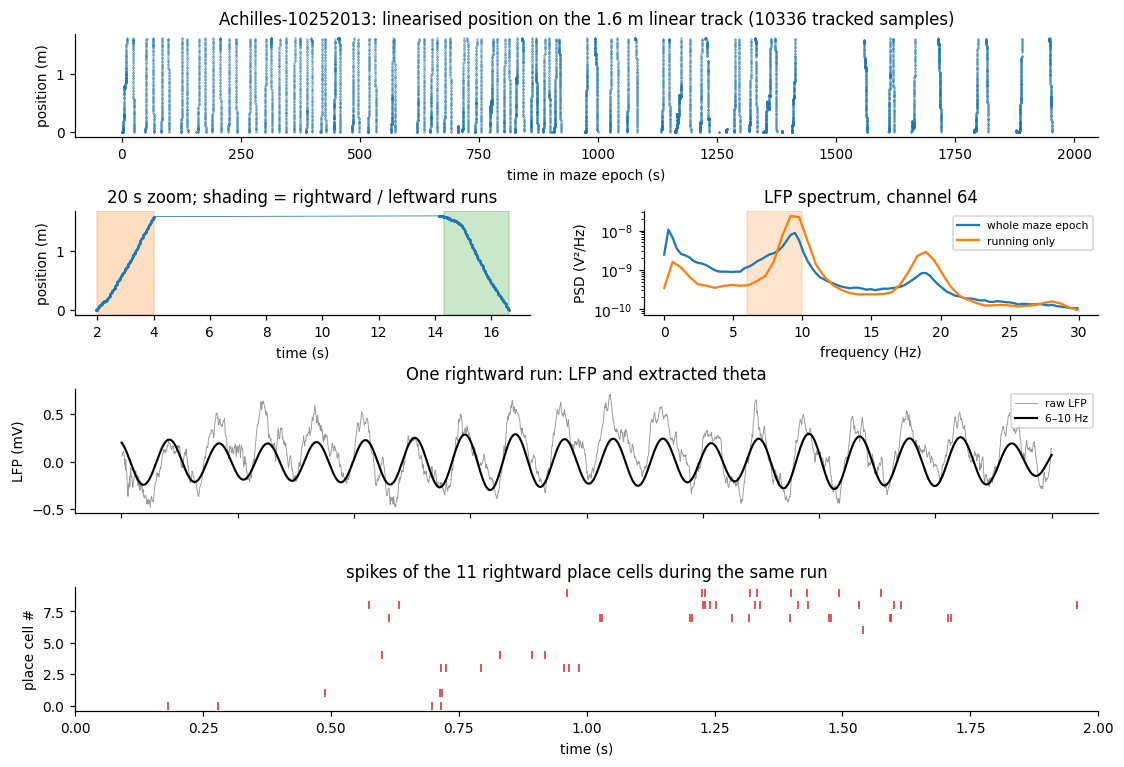

In [8]:
R = results[EXAMPLE]
pos, exc, eps, maze = R["pos"], R["exc"], R["eps"], R["maze"]
lfp, filt, phase, ch = R["lfp"], R["filt"], R["phase"], R["theta_ch"]
m0 = pos.index.values[0]

fig = plt.figure(figsize=(12, 8))
gs = GridSpec(4, 2, figure=fig, hspace=0.65, wspace=0.25, height_ratios=[1, 1, 1.2, 1.2])

ax = fig.add_subplot(gs[0, :])
ax.plot(pos.index.values - m0, pos.values, ".", ms=0.6, color="C0")
ax.set(xlabel="time in maze epoch (s)", ylabel="position (m)",
       title=f"{EXAMPLE}: linearised position on the {maze['length']} m linear track "
             f"({len(pos)} tracked samples)")

t0 = eps[1].start[10] - 2
ax = fig.add_subplot(gs[1, 0])
p = pos.restrict(nap.IntervalSet(start=t0, end=t0 + 20))
ax.plot(p.index.values - t0, p.values, ".-", ms=2, lw=0.5)
for d, col in ((1, "C1"), (-1, "C2")):
    for s, e in zip(eps[d].start, eps[d].end):
        if t0 <= s <= t0 + 20:
            ax.axvspan(s - t0, e - t0, color=col, alpha=0.25)
ax.set(xlabel="time (s)", ylabel="position (m)",
       title="20 s zoom; shading = rightward / leftward runs")

ax = fig.add_subplot(gs[1, 1])
fr, P = welch(lfp.values, fs=LFP_FS, nperseg=4096)
frr, Pr = welch(lfp.restrict(eps[1].union(eps[-1])).values, fs=LFP_FS, nperseg=2048)
ax.semilogy(fr[fr < 30], P[fr < 30], label="whole maze epoch")
ax.semilogy(frr[frr < 30], Pr[frr < 30], label="running only")
ax.axvspan(*THETA_BAND, color="C1", alpha=0.2)
ax.set(xlabel="frequency (Hz)", ylabel="PSD (V²/Hz)", title=f"LFP spectrum, channel {ch}")
ax.legend(fontsize=7)

ts = eps[1].start[10]
w2 = nap.IntervalSet(start=ts, end=ts + 2.0)
ax = fig.add_subplot(gs[2, :])
l, f = lfp.restrict(w2), filt.restrict(w2)
ax.plot(l.index.values - ts, l.values * 1e3, lw=0.6, color="0.6", label="raw LFP")
ax.plot(f.index.values - ts, f.values * 1e3, lw=1.4, color="k", label="6–10 Hz")
ax.set(ylabel="LFP (mV)", title="One rightward run: LFP and extracted theta")
ax.legend(fontsize=7, loc="upper right")
ax.set_xticklabels([])

ax = fig.add_subplot(gs[3, :])
fields = df[(df.session == EXAMPLE) & (df.direction == 1)].sort_values("lo")
for i, (_, r) in enumerate(fields.iterrows()):
    s = exc[int(r.unit)].restrict(w2)
    ax.plot(s.index.values - ts, np.full(len(s), i), "|", ms=5, color="C3")
ax.set(xlabel="time (s)", ylabel="place cell #", xlim=(0, 2.0),
       title=f"spikes of the {len(fields)} rightward place cells during the same run")
fig.savefig("fig01_session_overview.png", dpi=150, bbox_inches="tight")

## Figure 2: place fields

Sorted rate maps tile the track in both directions of travel, as expected for CA1 on a
linear track. The middle column shows the subset that passes the field criteria and
therefore enters the precession analysis.

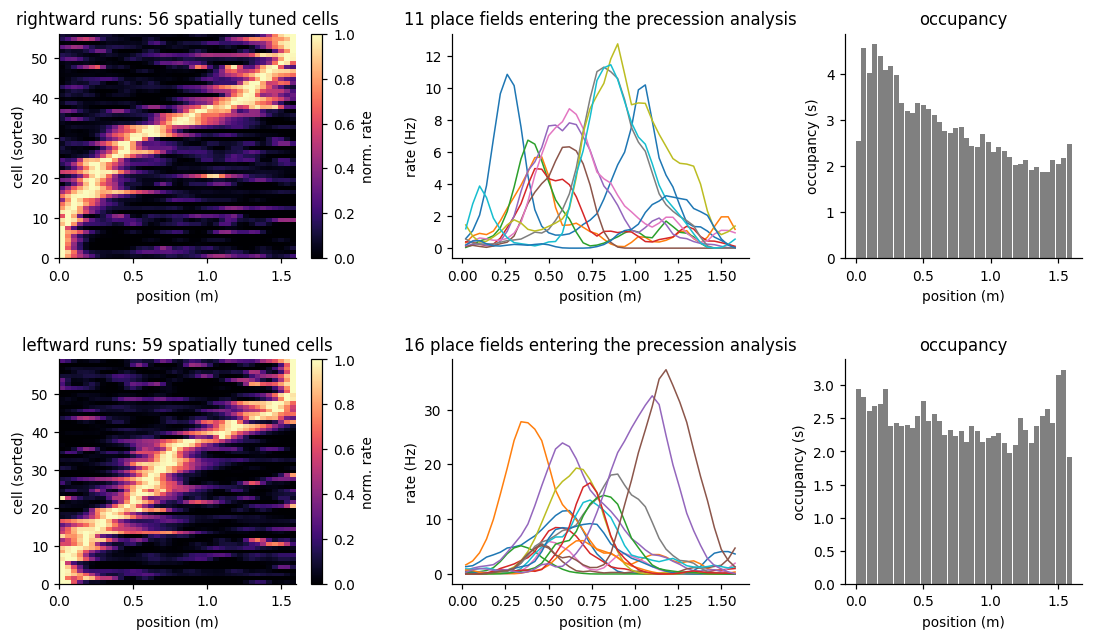

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6.5),
                         gridspec_kw={"width_ratios": [1, 1, 0.8], "hspace": 0.45, "wspace": 0.35})
for j, d in enumerate((1, -1)):
    tc, edges, occ, si = R["tcs"][d]
    centers = 0.5 * (edges[:-1] + edges[1:])
    keep = [u for u in tc.columns if tc[u].max() > MIN_PEAK and si[u] > MIN_SI]
    M = np.array([tc[u].values / tc[u].max() for u in keep])
    im = axes[j, 0].imshow(M[np.argsort(np.argmax(M, axis=1))], aspect="auto", origin="lower",
                           cmap="magma", extent=[0, maze["length"], 0, len(keep)])
    axes[j, 0].set(xlabel="position (m)", ylabel="cell (sorted)",
                   title=f"{'rightward' if d > 0 else 'leftward'} runs: "
                         f"{len(keep)} spatially tuned cells")
    plt.colorbar(im, ax=axes[j, 0], label="norm. rate")
    sel = df[(df.session == EXAMPLE) & (df.direction == d)].sort_values("lo")
    for _, r in sel.iterrows():
        axes[j, 1].plot(centers, tc[int(r.unit)].values, lw=1)
    axes[j, 1].set(xlabel="position (m)", ylabel="rate (Hz)",
                   title=f"{len(sel)} place fields entering the precession analysis")
    axes[j, 2].bar(centers, occ, width=POS_BIN * 0.9, color="0.5")
    axes[j, 2].set(xlabel="position (m)", ylabel="occupancy (s)", title="occupancy")
fig.savefig("fig02_place_fields.png", dpi=150, bbox_inches="tight")

## Figure 3: precession in individual place fields

Each column is one place field: its rate map on top (shaded region = the detected
field), and below it every in-field spike plotted as theta phase against the fraction
of the field traversed. Spikes are drawn over two theta cycles so the wrap-around is
visible; the red lines are the fitted regression, repeated one cycle apart.
`p = 0.005` is the floor of the 200-permutation test: no shuffle reached the observed
correlation.

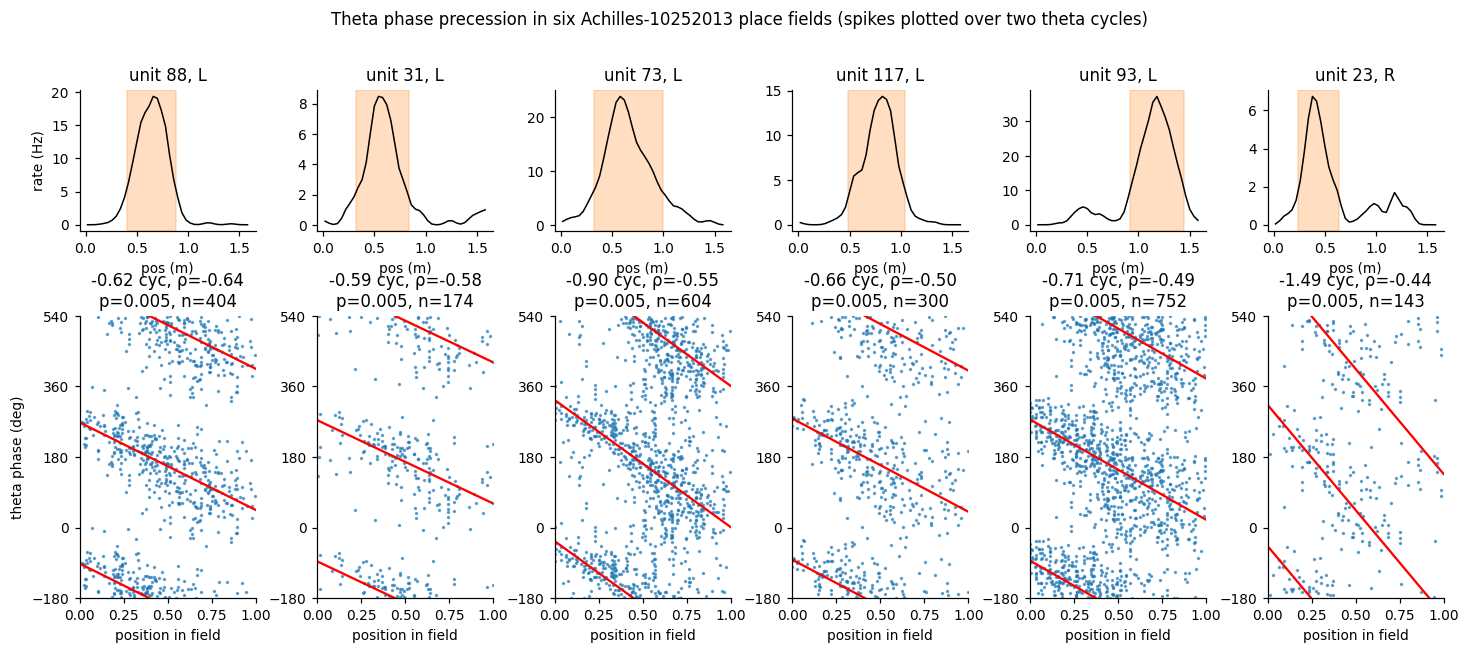

In [10]:
sel = df[(df.session == EXAMPLE) & (df.p < 0.05)].sort_values("rho").head(6)
fig, axes = plt.subplots(2, 6, figsize=(16, 6),
                         gridspec_kw={"height_ratios": [0.5, 1], "hspace": 0.4, "wspace": 0.35})
for k, (_, r) in enumerate(sel.iterrows()):
    d = int(r.direction)
    tc, edges, occ, si = R["tcs"][d]
    centers = 0.5 * (edges[:-1] + edges[1:])
    axes[0, k].plot(centers, tc[int(r.unit)].values, color="k", lw=1)
    axes[0, k].axvspan(r.lo, r.lo + r.width, color="C1", alpha=0.25)
    axes[0, k].set(title=f"unit {int(r.unit)}, {'R' if d > 0 else 'L'}", xlabel="pos (m)")
    x, ph, st = R["store"][(int(r.unit), d)]
    axes[1, k].plot(np.r_[x, x], np.degrees(np.r_[ph, ph + 2 * np.pi]), ".", ms=2.5, alpha=0.6)
    xx = np.linspace(0, 1, 50)
    for c in (-1, 0, 1, 2):
        axes[1, k].plot(xx, np.degrees(r.phi0 + 2 * np.pi * r.slope * xx) + 360 * c, "r-", lw=1.5)
    axes[1, k].set(ylim=(-180, 540), xlim=(0, 1), yticks=np.arange(-180, 541, 180),
                   xlabel="position in field",
                   title=f"{r.slope:.2f} cyc, ρ={r.rho:.2f}\np={r.p:.3f}, n={int(r.n)}")
axes[0, 0].set_ylabel("rate (Hz)")
axes[1, 0].set_ylabel("theta phase (deg)")
fig.suptitle(f"Theta phase precession in six {EXAMPLE} place fields "
             f"(spikes plotted over two theta cycles)", y=1.0)
fig.savefig("fig03_example_precession.png", dpi=150, bbox_inches="tight")

## Figure 4: precession within single traversals

Pooling spikes across traversals could in principle manufacture a phase-position
correlation that no single pass shows. The top two panels place each in-field spike on
the theta waveform of one traversal, coloured by how far through the field the animal
was: early spikes (dark) sit near the trough, later spikes (bright) move toward the
peak. The lower left panel fits each traversal separately.

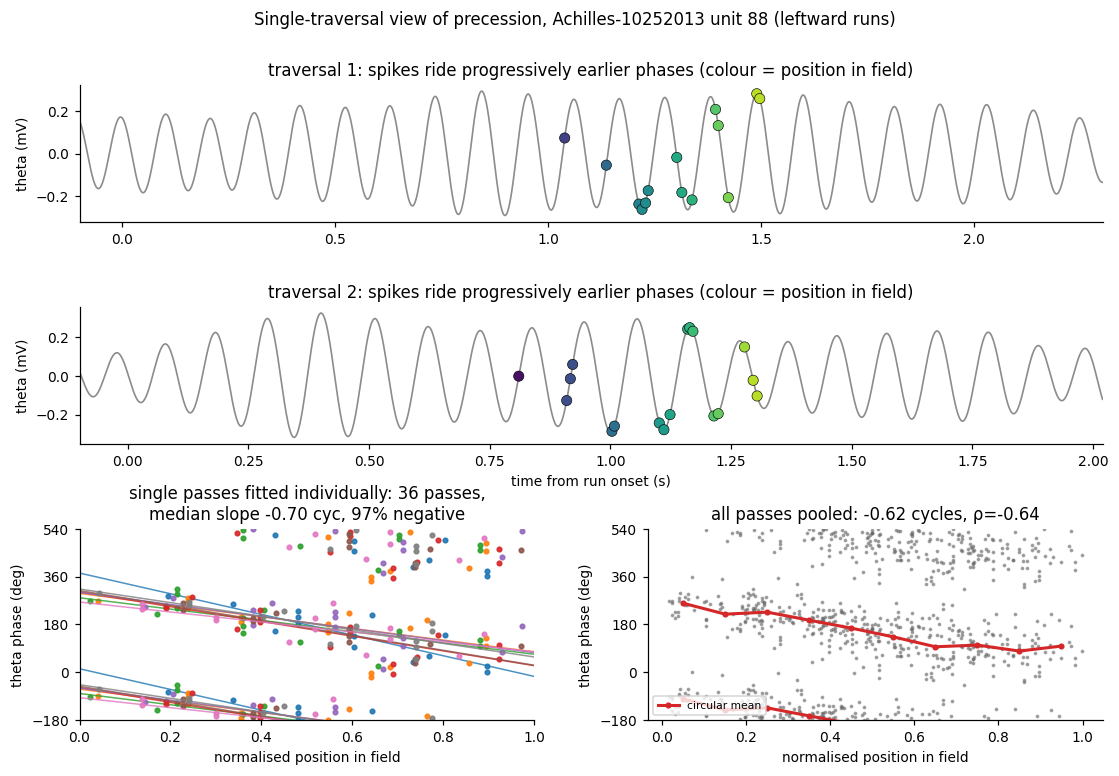

In [11]:
r = sel.iloc[0]
d, u = int(r.direction), int(r.unit)
ep = eps[d]
st_all = exc[u].restrict(ep).index.values
laps = []
for s, e in zip(ep.start, ep.end):
    m = (st_all >= s) & (st_all <= e)
    if m.sum() < 4:
        continue
    stl = st_all[m]
    xl = field_fraction(nap.Ts(t=stl).value_from(pos).values, r.lo, r.width, d, maze)
    inf = (xl >= 0) & (xl <= 1)
    if inf.sum() >= 4:
        laps.append((s, e, stl, xl, inf))

fig = plt.figure(figsize=(12, 7.5))
gs = GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.25, height_ratios=[1, 1, 1.4])
for k, (s, e, stl, xl, inf) in enumerate(laps[:2]):
    ax = fig.add_subplot(gs[k, :])
    f = filt.restrict(nap.IntervalSet(start=s - 0.1, end=e + 0.1))
    ax.plot(f.index.values - s, f.values * 1e3, color="0.55", lw=1.1)
    y = np.interp(stl[inf], f.index.values, f.values) * 1e3
    ax.scatter(stl[inf] - s, y, c=xl[inf], cmap="viridis", vmin=0, vmax=1, s=45,
               zorder=3, edgecolor="k", linewidth=0.4)
    ax.set(ylabel="theta (mV)", xlim=(-0.1, e - s + 0.1),
           title=f"traversal {k + 1}: spikes ride progressively earlier phases "
                 f"(colour = position in field)")
    if k == 1:
        ax.set_xlabel("time from run onset (s)")

ax = fig.add_subplot(gs[2, 0])
cmap, lap_slopes, xx = plt.get_cmap("tab10"), [], np.linspace(0, 1, 30)
for s, e, stl, xl, inf in laps:
    if inf.sum() < 6:
        continue
    ph_l = nap.Ts(t=stl[inf]).value_from(phase).values
    fit = circlin_fit(xl[inf], ph_l)
    lap_slopes.append(fit["slope"])
    if len(lap_slopes) <= 8:
        c = cmap(len(lap_slopes) - 1)
        ax.plot(np.r_[xl[inf], xl[inf]], np.degrees(np.r_[ph_l, ph_l + 2 * np.pi]),
                ".", ms=6, color=c, alpha=0.9)
        for k in (0, 1):
            ax.plot(xx, np.degrees(fit["phi0"] + 2 * np.pi * fit["slope"] * xx) + 360 * k,
                    "-", lw=1, color=c, alpha=0.8)
lap_slopes = np.array(lap_slopes)
ax.set(xlabel="normalised position in field", ylabel="theta phase (deg)", xlim=(0, 1),
       ylim=(-180, 540), yticks=np.arange(-180, 541, 180),
       title=f"single passes fitted individually: {len(lap_slopes)} passes,\n"
             f"median slope {np.median(lap_slopes):.2f} cyc, "
             f"{(lap_slopes < 0).mean() * 100:.0f}% negative")

ax = fig.add_subplot(gs[2, 1])
x, ph, _ = R["store"][(u, d)]
ax.plot(np.r_[x, x], np.degrees(np.r_[ph, ph + 2 * np.pi]), ".", ms=3, alpha=0.5, color="0.4")
edges_x = np.linspace(0, 1, 11)
mu = np.degrees(np.unwrap([np.angle(np.exp(1j * ph[(x >= a) & (x < b)]).mean())
                           for a, b in zip(edges_x[:-1], edges_x[1:])]))
xc = 0.5 * (edges_x[:-1] + edges_x[1:])
ax.plot(xc, mu, "C3.-", lw=2, label="circular mean")
ax.plot(xc, mu + 360, "C3.-", lw=2)
ax.set(ylim=(-180, 540), yticks=np.arange(-180, 541, 180), xlabel="normalised position in field",
       ylabel="theta phase (deg)", title=f"all passes pooled: {r.slope:.2f} cycles, ρ={r.rho:.2f}")
ax.legend(fontsize=7, loc="lower left")
fig.suptitle(f"Single-traversal view of precession, {EXAMPLE} unit {u} "
             f"({'rightward' if d > 0 else 'leftward'} runs)", y=0.97)
fig.savefig("fig04_single_pass.png", dpi=150, bbox_inches="tight")

## Figure 5: population summary

Pooling every field from all eight sessions. The slope distribution sits clearly to the
left of zero, every session has a negative median, and the spikes of all significant
fields pooled together trace a continuous phase advance of roughly 200° across the
field.

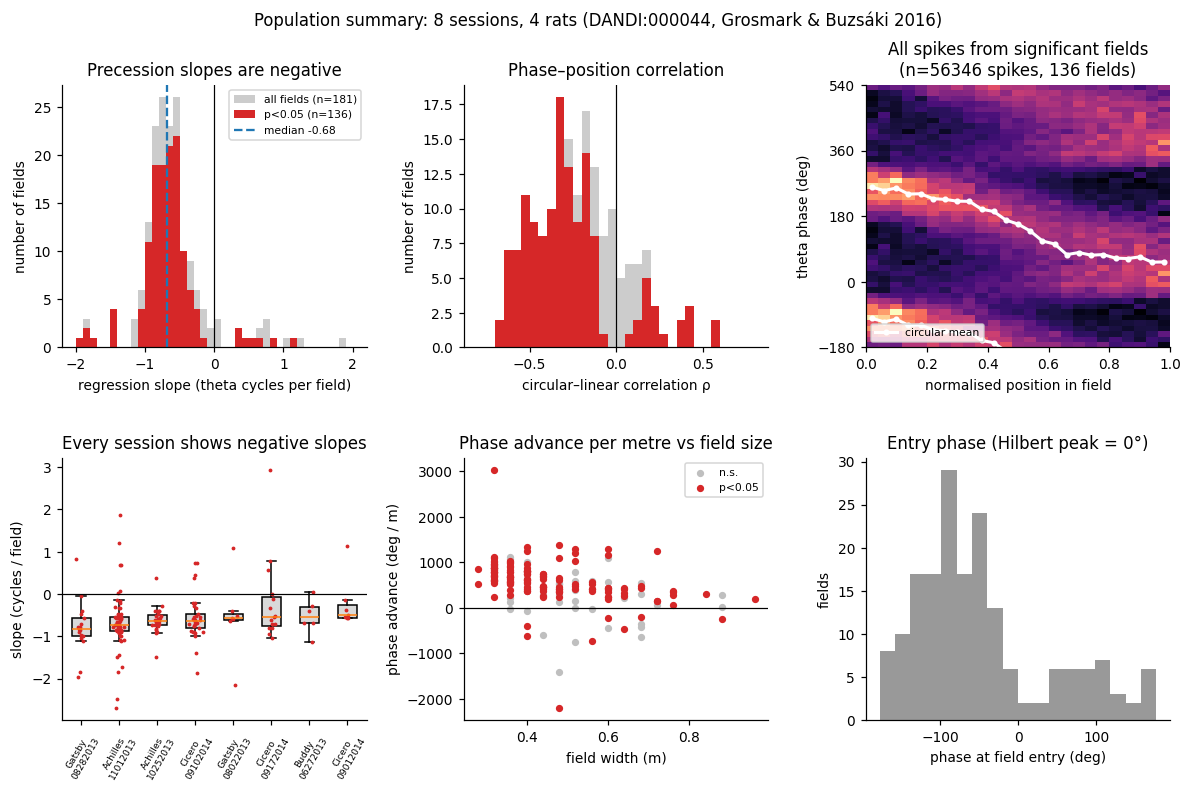

In [12]:
sig = df[df.p < 0.05]
sigkeys = {(t.session, int(t.unit), int(t.direction)) for t in sig.itertuples()}
sX = np.concatenate([v[0] for s in results for k, v in results[s]["store"].items()
                     if (s, k[0], k[1]) in sigkeys])
sP = np.concatenate([v[1] for s in results for k, v in results[s]["store"].items()
                     if (s, k[0], k[1]) in sigkeys])

fig = plt.figure(figsize=(13, 7.5))
gs = GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.32)

ax = fig.add_subplot(gs[0, 0])
bins = np.arange(-2.0, 2.01, 0.1)
ax.hist(df.slope, bins=bins, color="0.8", label=f"all fields (n={len(df)})")
ax.hist(sig.slope, bins=bins, color="C3", label=f"p<0.05 (n={len(sig)})")
ax.axvline(0, color="k", lw=0.8)
ax.axvline(df.slope.median(), color="C0", ls="--", label=f"median {df.slope.median():.2f}")
ax.set(xlabel="regression slope (theta cycles per field)", ylabel="number of fields",
       title="Precession slopes are negative")
ax.legend(fontsize=7)

ax = fig.add_subplot(gs[0, 1])
ax.hist(df.rho, bins=np.arange(-0.8, 0.81, 0.05), color="0.8")
ax.hist(sig.rho, bins=np.arange(-0.8, 0.81, 0.05), color="C3")
ax.axvline(0, color="k", lw=0.8)
ax.set(xlabel="circular–linear correlation ρ", ylabel="number of fields",
       title="Phase–position correlation")

ax = fig.add_subplot(gs[0, 2])
H, xe, ye = np.histogram2d(np.r_[sX, sX], np.degrees(np.r_[sP, sP + 2 * np.pi]),
                           bins=[np.linspace(0, 1, 26), np.linspace(-180, 540, 49)])
ax.pcolormesh(xe, ye, (H / H.sum(axis=1, keepdims=True)).T, cmap="magma")
xc = 0.5 * (xe[:-1] + xe[1:])
mu = np.degrees(np.unwrap([np.angle(np.exp(1j * sP[(sX >= a) & (sX < b)]).mean())
                           for a, b in zip(xe[:-1], xe[1:])]))
ax.plot(xc, mu, "w.-", lw=2, label="circular mean")
ax.plot(xc, mu + 360, "w.-", lw=2)
ax.set(xlabel="normalised position in field", ylabel="theta phase (deg)",
       ylim=(-180, 540), yticks=np.arange(-180, 541, 180),
       title=f"All spikes from significant fields\n(n={len(sX)} spikes, {len(sig)} fields)")
ax.legend(fontsize=7, loc="lower left")

ax = fig.add_subplot(gs[1, 0])
order = df.groupby("session").slope.median().sort_values().index
bp = ax.boxplot([df[df.session == s].slope.values for s in order], vert=True,
                tick_labels=[s.replace("-", "\n") for s in order],
                showfliers=False, patch_artist=True)
for b in bp["boxes"]:
    b.set_facecolor("0.85")
for i, s in enumerate(order):
    v = df[df.session == s].slope.values
    ax.plot(np.random.default_rng(i).normal(i + 1, 0.06, len(v)), v, ".", ms=3, color="C3")
ax.axhline(0, color="k", lw=0.8)
ax.set(ylabel="slope (cycles / field)", title="Every session shows negative slopes")
ax.tick_params(axis="x", labelsize=6, rotation=60)

ax = fig.add_subplot(gs[1, 1])
ns = df.p >= 0.05
ax.scatter(df.width[ns], (-df.slope * 360 / df.width)[ns], c="0.75", s=14, label="n.s.")
ax.scatter(df.width[~ns], (-df.slope * 360 / df.width)[~ns], c="C3", s=14, label="p<0.05")
ax.axhline(0, color="k", lw=0.8)
ax.legend(fontsize=7)
ax.set(xlabel="field width (m)", ylabel="phase advance (deg / m)",
       title="Phase advance per metre vs field size")

ax = fig.add_subplot(gs[1, 2])
ax.hist(np.degrees(np.mod(df.phi0 + np.pi, 2 * np.pi) - np.pi), bins=18, color="0.6")
ax.set(xlabel="phase at field entry (deg)", ylabel="fields",
       title="Entry phase (Hilbert peak = 0°)")
fig.suptitle("Population summary: 8 sessions, 4 rats "
             "(DANDI:000044, Grosmark & Buzsáki 2016)", y=0.97)
fig.savefig("fig05_population.png", dpi=150, bbox_inches="tight")

## Figure 6: controls

Four checks that the effect is not an artefact of the analysis. Shuffling phases within
each field destroys it, so neither the fitting procedure nor the field geometry can
generate a negative slope on its own. Theta phase is sampled uniformly during running,
so the result is not an artefact of uneven phase occupancy. And both directions of
travel precess, which they would not if the sign came from the direction-dependent
flip of the position coordinate.

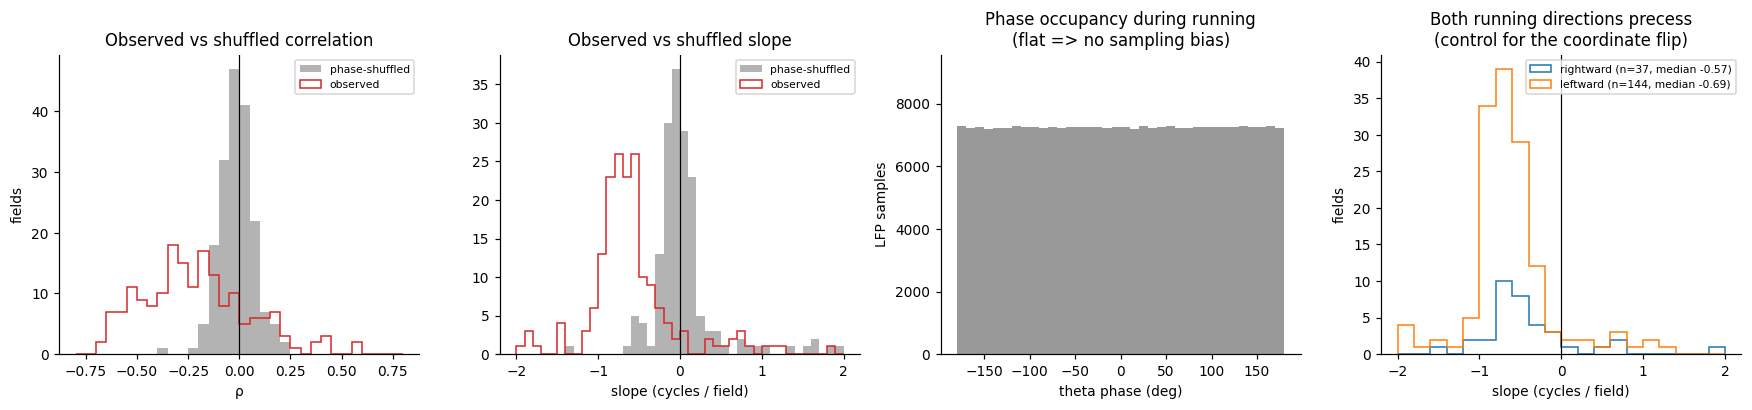

In [13]:
rng = np.random.default_rng(1)
null = [circlin_fit(v[0], rng.permutation(v[1]))
        for s in results for v in results[s]["store"].values()]
null_rho = [f["rho"] for f in null]
null_slope = [f["slope"] for f in null]
ph_run = phase.restrict(eps[1].union(eps[-1])).values

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
axes[0].hist(null_rho, bins=np.arange(-0.8, 0.81, 0.05), color="0.7", label="phase-shuffled")
axes[0].hist(df.rho, bins=np.arange(-0.8, 0.81, 0.05), histtype="step", color="C3", lw=2,
             label="observed")
axes[0].axvline(0, color="k", lw=0.8)
axes[0].legend(fontsize=7)
axes[0].set(xlabel="ρ", ylabel="fields", title="Observed vs shuffled correlation")

axes[1].hist(null_slope, bins=np.arange(-2, 2.01, 0.1), color="0.7", label="phase-shuffled")
axes[1].hist(df.slope, bins=np.arange(-2, 2.01, 0.1), histtype="step", color="C3", lw=2,
             label="observed")
axes[1].axvline(0, color="k", lw=0.8)
axes[1].legend(fontsize=7)
axes[1].set(xlabel="slope (cycles / field)", title="Observed vs shuffled slope")

axes[2].hist(np.degrees(ph_run), bins=36, color="0.6")
axes[2].set(xlabel="theta phase (deg)", ylabel="LFP samples",
            title="Phase occupancy during running\n(flat => no sampling bias)")
axes[2].set_ylim(0, axes[2].get_ylim()[1] * 1.25)

for d, c, lab in ((1, "C0", "rightward"), (-1, "C1", "leftward")):
    v = df[df.direction == d].slope
    axes[3].hist(v, bins=np.arange(-2, 2.01, 0.2), histtype="step", lw=2, color=c,
                 label=f"{lab} (n={len(v)}, median {v.median():.2f})")
axes[3].axvline(0, color="k", lw=0.8)
axes[3].legend(fontsize=7)
axes[3].set(xlabel="slope (cycles / field)", ylabel="fields",
            title="Both running directions precess\n(control for the coordinate flip)")
fig.tight_layout()
fig.savefig("fig06_controls.png", dpi=150, bbox_inches="tight")

## Results

In [14]:
print(f"place fields analysed:            {len(df)}")
print(f"significant (shuffle p < 0.05):   {len(sig)}  ({100 * len(sig) / len(df):.0f} %)")
print(f"  of those, negative slope:       {100 * (sig.slope < 0).mean():.0f} %")
print(f"median slope, all fields:         {df.slope.median():.2f} theta cycles per field")
print(f"median slope, significant fields: {sig.slope.median():.2f} cycles "
      f"({-sig.slope.median() * 360:.0f} deg of phase advance)")
print(f"median circular-linear rho:       {sig.rho.median():.2f}")
print(f"phase advance across the field:   {mu[0] - mu[-1]:.0f} deg (population circular mean)")
print()
print(df.groupby("session").agg(fields=("slope", "size"),
                                median_slope=("slope", "median"),
                                frac_negative=("slope", lambda s: (s < 0).mean().round(2))))

place fields analysed:            181
significant (shuffle p < 0.05):   136  (75 %)
  of those, negative slope:       94 %
median slope, all fields:         -0.68 theta cycles per field
median slope, significant fields: -0.68 cycles (245 deg of phase advance)
median circular-linear rho:       -0.31
phase advance across the field:   205 deg (population circular mean)

                   fields  median_slope  frac_negative
session                                               
Achilles-10252013      27        -0.640           0.96
Achilles-11012013      69        -0.740           0.91
Buddy-06272013          6        -0.535           0.83
Cicero-09012014         7        -0.500           0.86
Cicero-09102014        33        -0.630           0.88
Cicero-09172014        15        -0.550           0.80
Gatsby-08022013         7        -0.560           0.86
Gatsby-08282013        17        -0.830           0.94


## Interpretation

Across 8 sessions from 4 rats the analysis recovers theta phase precession as
originally described. Of the place fields that met the selection criteria, three
quarters show a phase-position relationship stronger than chance, and 94 % of those
advance in phase rather than retreat. The median field advances by about two thirds of
a theta cycle (roughly 240°) from entry to exit, which is within the range usually
reported for single fields on linear tracks; the pooled population average traces a
smooth advance of about 200° across the normalised field.

Three features support the interpretation that this is the real phenomenon rather than
an analysis artefact. It survives at the level of single traversals, where the animal
passes through the field only once and no averaging across passes is involved. It
reverses to a flat, zero-centred distribution when spike phases are shuffled within the
field. And it appears with the same sign for both directions of travel, even though the
linearised position coordinate runs the opposite way in the two cases.

The absolute phase at field entry is not directly interpretable here. The theta
reference channel was chosen automatically as the one with the largest theta-to-
background power ratio, which in these probe recordings tends to sit near the
hippocampal fissure rather than in the pyramidal layer, and the phase offset between
those depths is roughly 180°. Comparing entry phases across sessions would require
anatomically registering the reference channel; the slope, which is what precession is
about, does not depend on that choice.